# Phase-Shear Readout with ais++

This notebook walks through the complete ais++ workflow for a **Phase-Shear Readout (PSR)**
Mach–Zehnder atom interferometer:

1. **Run the simulation** — call `ais++` with the provided input file to produce an HDF5 output.
2. **Load the output** — read positions, states, and phase shifts from the HDF5 file.
3. **Fit the fringe pattern** — extract the fringe wave-vector $\kappa$, phase $\varphi_0$,
   and contrast $C$ by fitting the transverse atom distribution.
4. **Visualise** — reproduce the PSR readout figure from
   [Mouelle et al. (2025)](https://arxiv.org/abs/2510.26739).

**Setup**

```bash
# Install Python dependencies
pip install numpy scipy matplotlib h5py pandas jupyter

# Step 1 — run the simulation (takes ~0.1 s for n=1, ~120 s for 1M atoms)
cd examples/
ais++ -i input-files/PSR_EXAMPLE_NLMT1.aisi -o output-files/PSR_EXAMPLE_NLMT1.h5

# Step 2 — open this notebook and run all cells
jupyter notebook example_1.ipynb
```

A pre-generated output file is already included in `output-files/` so you can run the
notebook without building ais++ first. No external analysis library is required beyond
the small `analysis.py` helper in this folder.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from analysis import load_data   # local helper — no external dependencies

# ── style (matches the paper figures) ────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-ticks')
except OSError:
    plt.style.use('seaborn-ticks')

plt.rcParams.update({
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'Times', 'Palatino'],
    'text.usetex'        : True,
    'text.latex.preamble': r'\usepackage{times}',
    'font.size'          : 9,
    'axes.titlesize'     : 9,
    'axes.labelsize'     : 9,
    'lines.linewidth'    : 1.0,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'xtick.direction'    : 'in',
    'ytick.direction'    : 'in',
    'xtick.major.size'   : 3,
    'ytick.major.size'   : 3,
    'legend.fontsize'    : 7,
    'legend.frameon'     : False,
    'savefig.dpi'        : 300,
})

## 1. Load simulation output

The HDF5 file produced by ais++ contains the final position, velocity, internal state,
and accumulated phase shift of every simulated atom.
We select only **interfering ground-state atoms**
($\texttt{states}=0$, $\texttt{interference\_flag}=1$).

In [15]:
df   = load_data('output-files/PSR_EXAMPLE_NLMT1.h5')
mask = (df['states'] == 0) & (df['interference_flag'] == 1)
g    = df[mask]

print(f"Total atoms          : {len(df):,}")
print(f"Interfering (ground) : {mask.sum():,}")
print(f"Transverse σ_x       : {g['x'].std()*1e3:.2f} mm")
print(f"Mean phase shift     : {g['phase_shifts'].mean():.6e} rad")

g.head()

Total atoms          : 999,468
Interfering (ground) : 499,482
Transverse σ_x       : 1.38 mm
Mean phase shift     : -4.370365e+08 rad


,states,x,y,z,vx,vy,vz,phase_shifts,phase_shifts_errors,interference_flag
0,0,0.002117,0.001409,-9.831659,0.000479,0.000291,-24.04431,-4.370365e+08,0.0,1
1,0,0.001929,0.000798,-9.831812,0.000443,0.000175,-24.04431,-4.370365e+08,0.0,1
5,0,-0.000219,0.002606,-9.831454,-0.000048,0.000574,-24.04431,-4.370365e+08,0.0,1
8,0,-0.001673,0.001651,-9.831752,-0.000343,0.000385,-24.04431,-4.370365e+08,0.0,1
9,0,0.000114,0.001353,-9.831418,0.000021,0.000362,-24.04431,-4.370365e+08,0.0,1


## 2. Fit the PSR fringe pattern

The Phase-Shear Readout applies a momentum kick $\hbar\kappa_\mathrm{PSR}$ to one arm of
the interferometer, imprinting a spatially periodic modulation on the detected atom density:

$$N(x) = A\left[1 + C\cos(\kappa x + \varphi_0)\right]
         \exp\!\left(-\frac{(x-\mu_x)^2}{2\sigma^2}\right)$$

Fitting the $x$-projection histogram yields the fringe wave-vector $\kappa$,
phase $\varphi_0$ (the interferometer output), and contrast $C$.

In [16]:
def fringe_model(x, A, sigma, mux, kappa, phi0, C):
    """Gaussian-envelope × cosine fringe (PSR readout model)."""
    return A * (1 + C*np.cos(kappa*x + phi0)) * np.exp(-(x-mux)**2 / (2*sigma**2))

def gauss_env(x, A, sigma, mux):
    return A * np.exp(-(x-mux)**2 / (2*sigma**2))

x_g = g['x'].values
counts, bin_edges = np.histogram(x_g, bins=80)
xc   = 0.5 * (bin_edges[:-1] + bin_edges[1:])
serr = np.where(counts > 0, np.sqrt(counts), 1.0)

p0     = [counts.max(), x_g.std(), x_g.mean(), 3140., 2.4, 0.95]
bounds = ([0, 0, -0.003, 500, -np.pi, 0.0],
          [np.inf, 0.01, 0.003, 20000, np.pi, 1.0])
popt, pcov = curve_fit(fringe_model, xc, counts,
                       p0=p0, sigma=serr, bounds=bounds, maxfev=20000)
perr = np.sqrt(np.diag(pcov))

labels = ['A (atoms)', 'σ (m)', 'μ_x (m)', 'κ (rad/m)', 'φ₀ (rad)', 'C']
for lab, val, err in zip(labels, popt, perr):
    print(f"  {lab:12s} = {val: .5g}  ±  {err:.2g}")

  A (atoms)    =  22194  ±  47
  σ (m)        =  0.0013792  ±  1.7e-06
  μ_x (m)      =  4.0946e-07  ±  2.4e-06
  κ (rad/m)    =  3137.4  ±  1.4
  φ₀ (rad)     =  0.35741  ±  0.0019
  C            =  0.9884  ±  0.00081


## 3. Visualise

**Top**: 2-D histogram of ground-state atom positions in the transverse ($x$, $y$) plane.
The PSR kick creates a grating-like pattern; the fringe phase encodes the interferometer output.

**Bottom**: $x$-projection with the fitted fringe model (pink) and its Gaussian envelope (dashed).

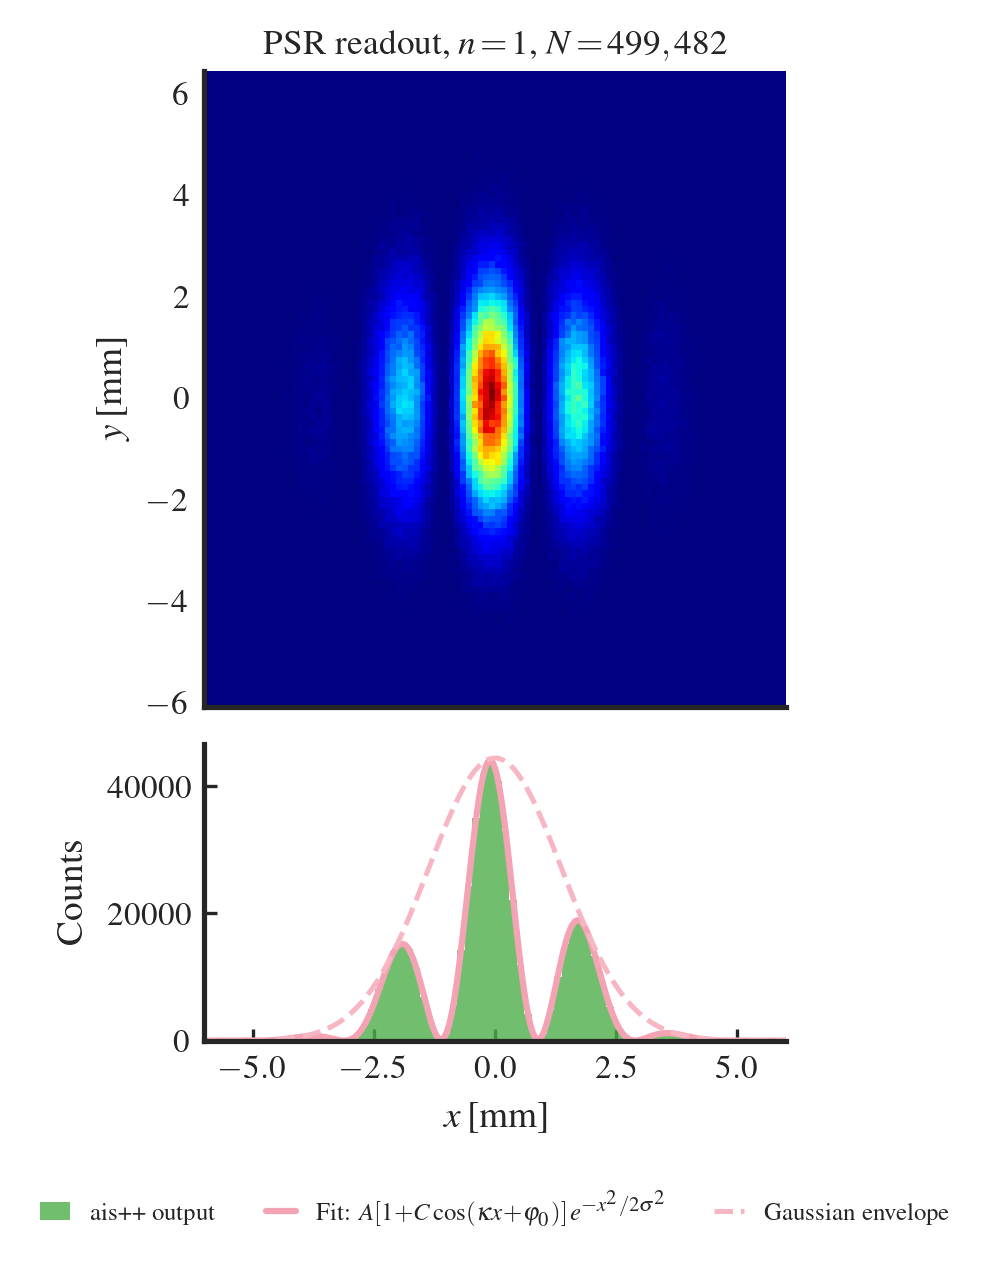

Fitted:  κ = 3137 rad/m,  C = 0.988,  φ₀ = 0.357 rad


In [20]:
C_BAR = '#4daf4a'
C_FIT = '#f4a3b4'
C_ENV = '#f7b6c2'

y_g = g['y'].values
N   = len(g)

fig, (ax2d, ax1d) = plt.subplots(
    2, 1, figsize=(2.5, 4.2), dpi=300,
    gridspec_kw=dict(hspace=0.08, height_ratios=[3, 1.4]),
)

# ── 2D atom cloud ─────────────────────────────────────────────────────────────
ax2d.set_facecolor(plt.cm.jet(0.0))
ax2d.hist2d(x_g*1e3, y_g*1e3, bins=100, cmap='jet')
ax2d.set_title(r'PSR readout, $n\!=\!1$, $N\!=\!{:,}$'.format(N), fontsize=8.5, pad=4)
ax2d.set_ylabel(r'$y$\,[mm]')
ax2d.tick_params(labelbottom=False)

# ── 1D fringe projection + fit ────────────────────────────────────────────────
bw   = (xc[1] - xc[0]) * 1e3
xfit = np.linspace(x_g.min(), x_g.max(), 600)

bar_h = ax1d.bar(xc*1e3, counts, width=bw, color=C_BAR, alpha=0.80, linewidth=0)
fit_l,= ax1d.plot(xfit*1e3, fringe_model(xfit, *popt), color=C_FIT, lw=1.5)
env_l,= ax1d.plot(xfit*1e3, 2*gauss_env(xfit, popt[0], popt[1], popt[2]),
                  color=C_ENV, lw=1.2, ls='--')

ax1d.set_xlim(-6, 6)
ax1d.set_ylim(0, None)
ax1d.set_xlabel(r'$x$\,[mm]')
ax1d.set_ylabel(r'Counts')
ax1d.legend(
    [bar_h, fit_l, env_l],
    ['ais++ output',
     r'Fit: $A[1\!+\!C\cos(\kappa x\!+\!\varphi_0)]\,e^{-x^2/2\sigma^2}$',
     'Gaussian envelope'],
    loc='lower center', bbox_to_anchor=(0.5, -0.7), ncol=3, fontsize=6, handlelength=1.2,
)

fig.savefig('wavefront_aberration_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Fitted:  κ = {popt[3]:.0f} rad/m,  C = {popt[5]:.3f},  φ₀ = {popt[4]:.3f} rad")